<a href="https://colab.research.google.com/github/cu24250216-oss/Computer-Vision-Experiments/blob/main/TANISHASINGH_60_EXPERIMENT_08_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Experiment No.8**

**Application of Optical Flow for Real-Time Object Tracking and Motion Analysis**

In [1]:
import cv2
import numpy as np
from google.colab import files
from google.colab.patches import cv2_imshow

uploaded = files.upload()
video_path = list(uploaded.keys())[0]

print("Video uploaded:", video_path)

Saving optical_flow_sample.mp4 to optical_flow_sample.mp4
Video uploaded: optical_flow_sample.mp4


Video opened: True
Frame read: True


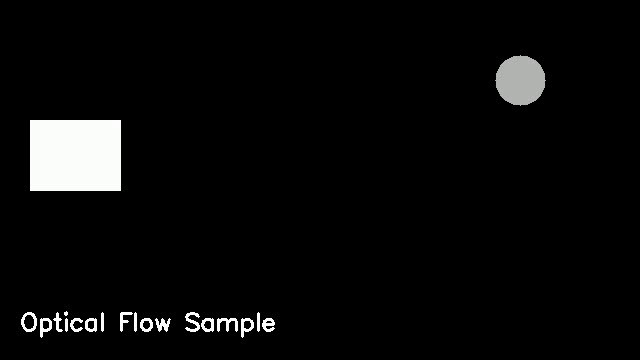

In [2]:
cap = cv2.VideoCapture(video_path)

ret, frame = cap.read()

print("Video opened:", cap.isOpened())
print("Frame read:", ret)

if ret:
    cv2_imshow(frame)

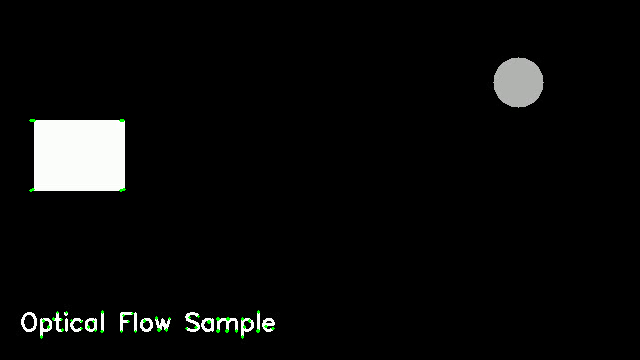

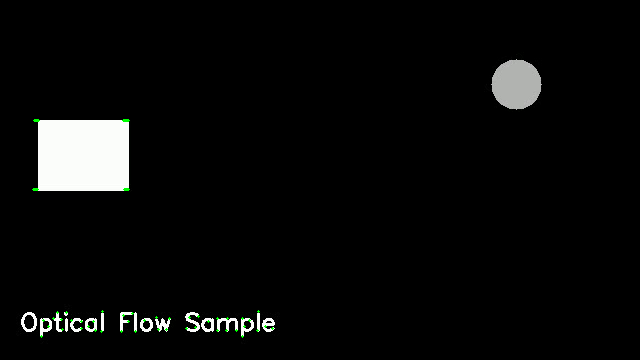

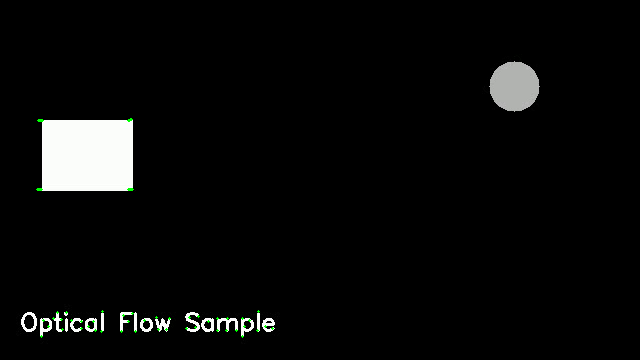

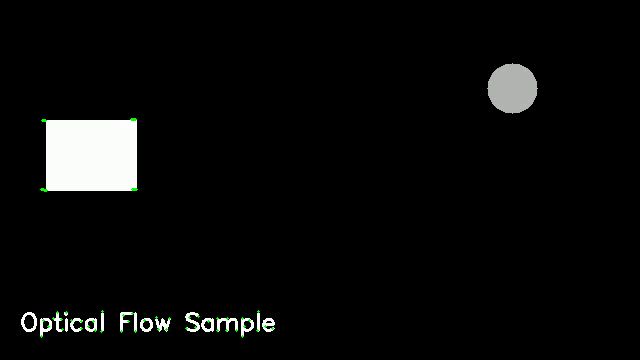

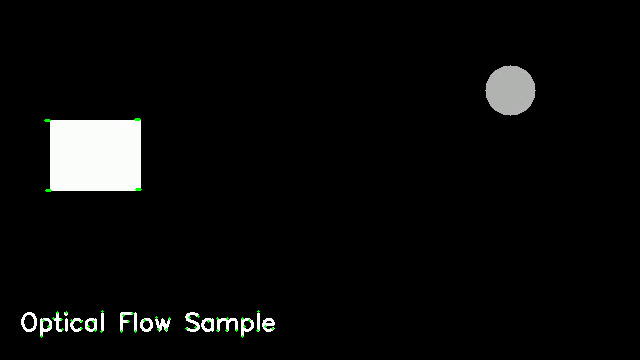

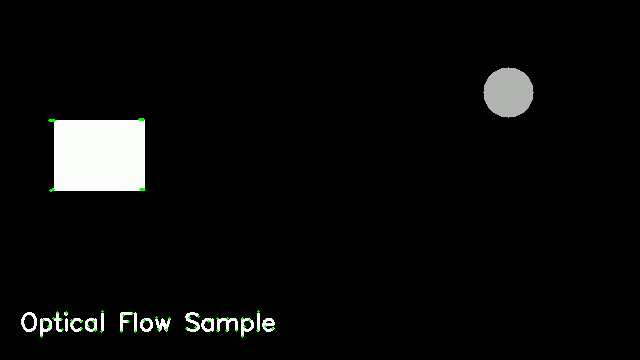

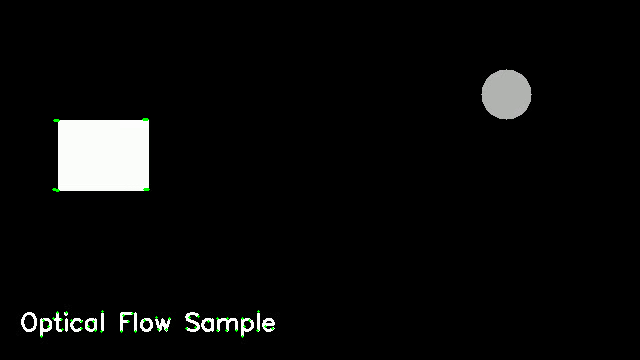

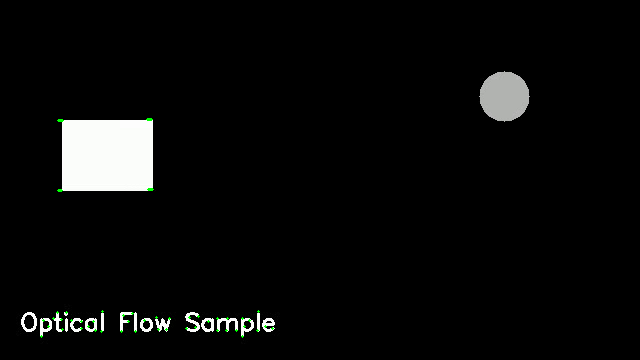

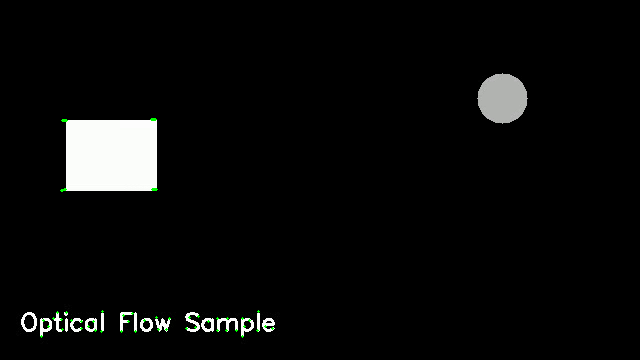

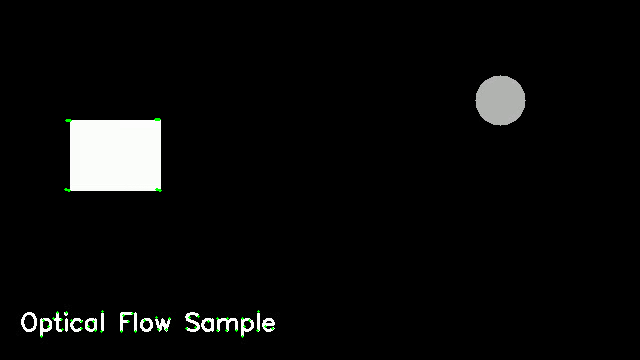

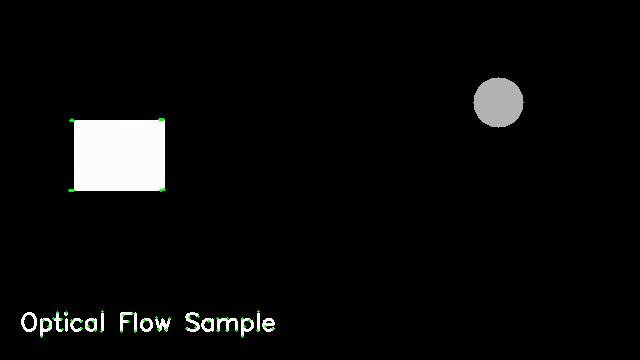

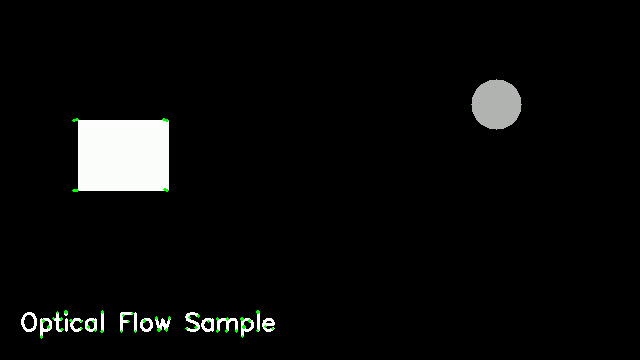

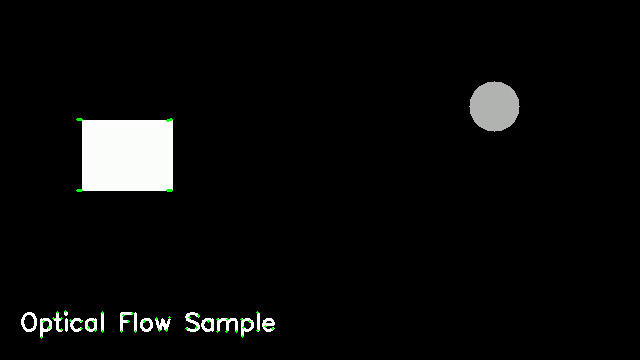

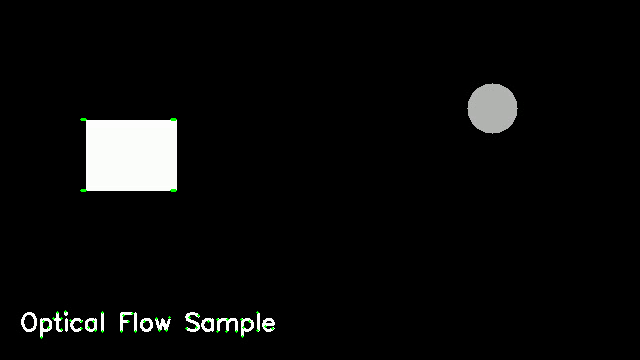

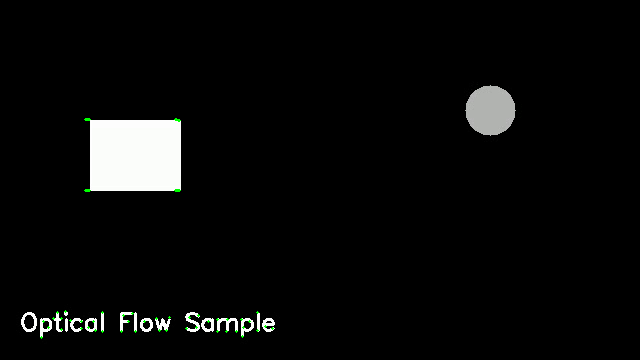

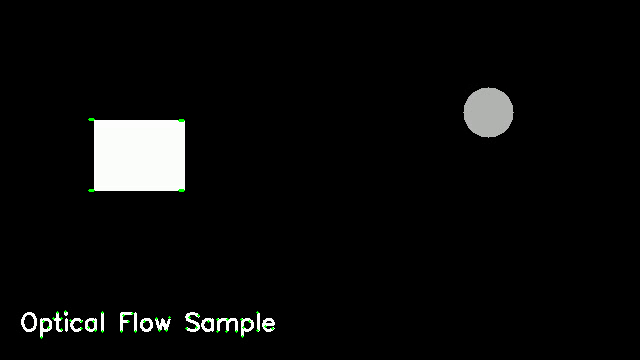

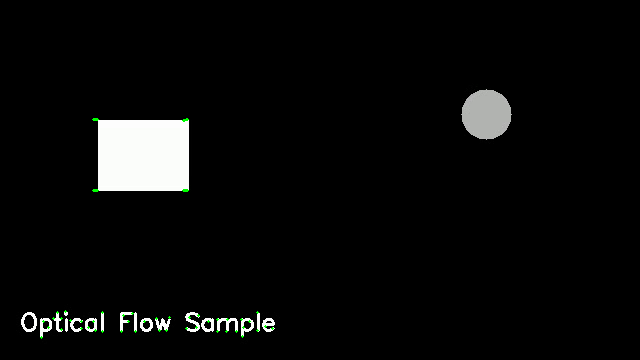

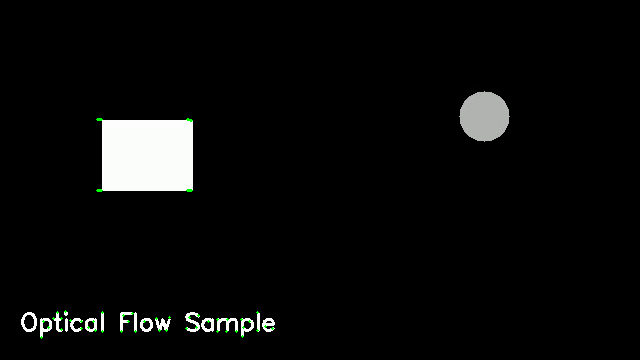

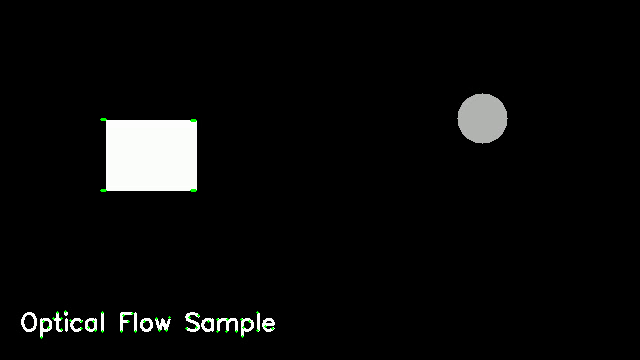

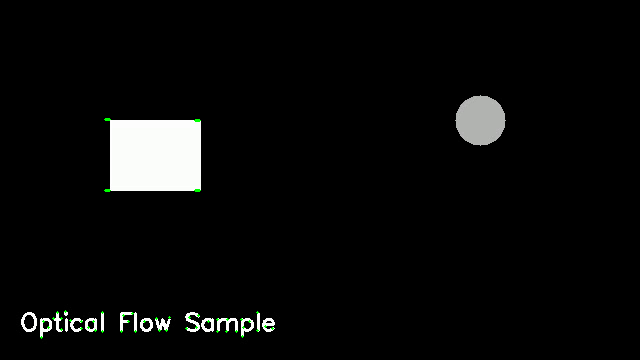

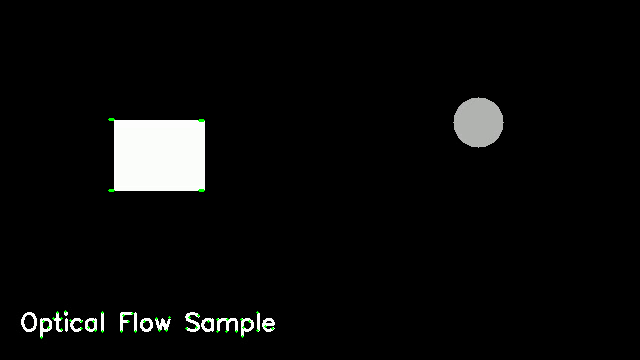

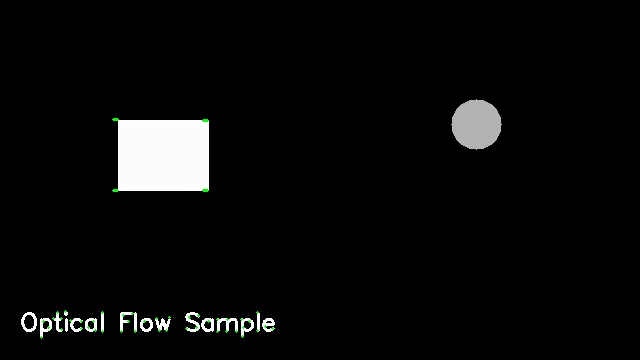

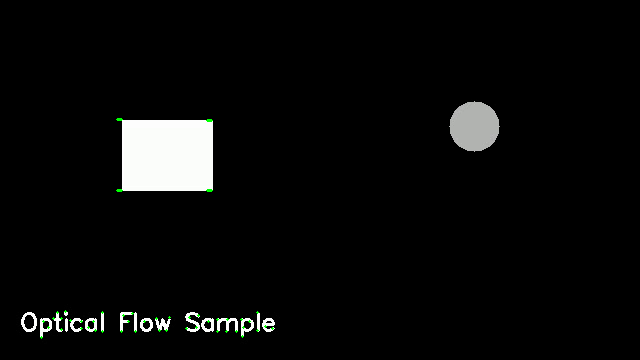

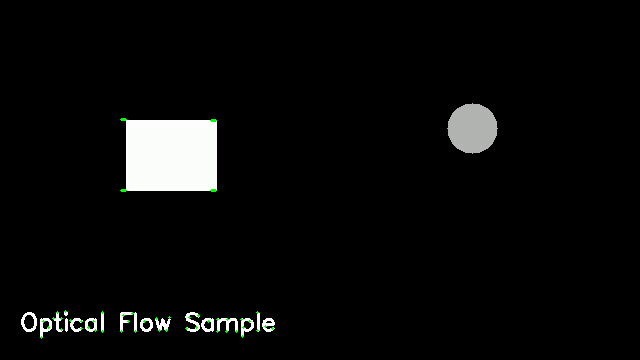

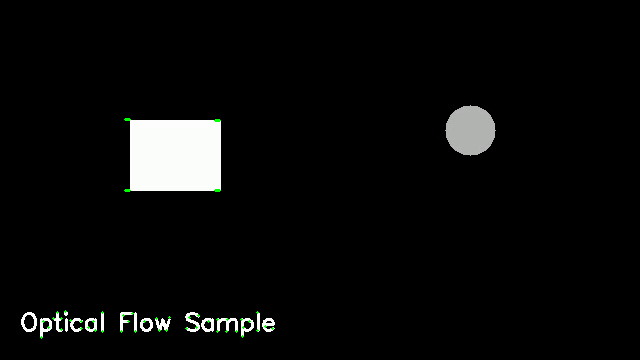

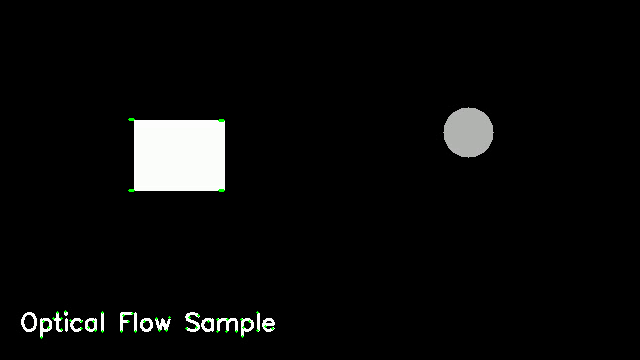

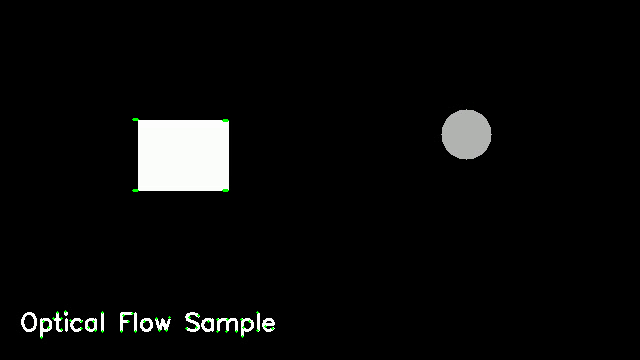

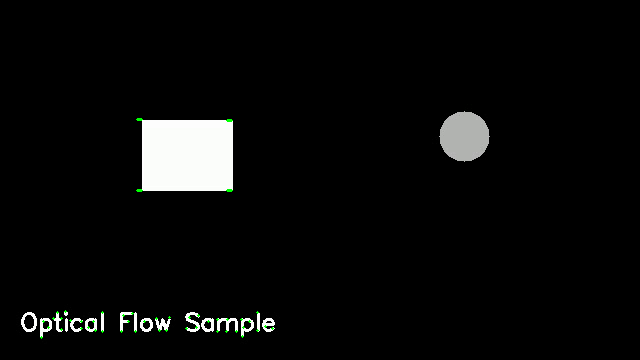

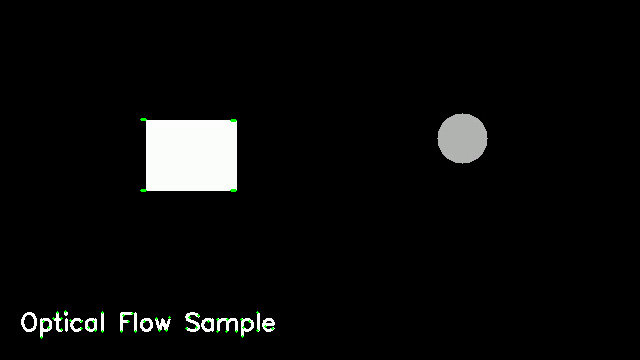

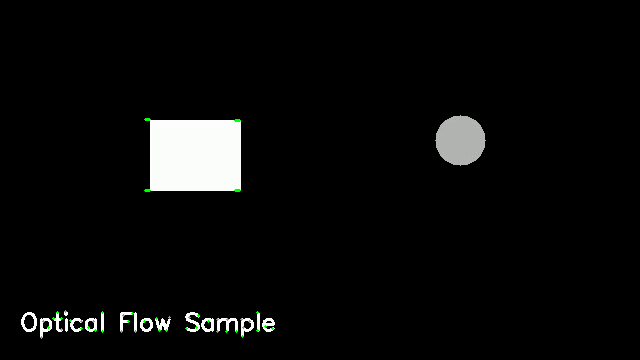

In [3]:
cap = cv2.VideoCapture(video_path)

ret, old_frame = cap.read()

old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)

p0 = cv2.goodFeaturesToTrack(
    old_gray, maxCorners=100,
    qualityLevel=0.3, minDistance=7
)

for i in range(30):

    ret, frame = cap.read()

    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    p1, status, error = cv2.calcOpticalFlowPyrLK(
        old_gray, gray, p0, None
    )

    if p1 is None:
        break

    good_new = p1[status == 1]
    good_old = p0[status == 1]

    for new, old in zip(good_new, good_old):

        x1, y1 = new.ravel().astype(int)
        x2, y2 = old.ravel().astype(int)

        cv2.arrowedLine(
            frame, (x2, y2), (x1, y1),
            (0, 255, 0), 2
        )

    cv2_imshow(frame)

    old_gray = gray.copy()
    p0 = good_new.reshape(-1, 1, 2)

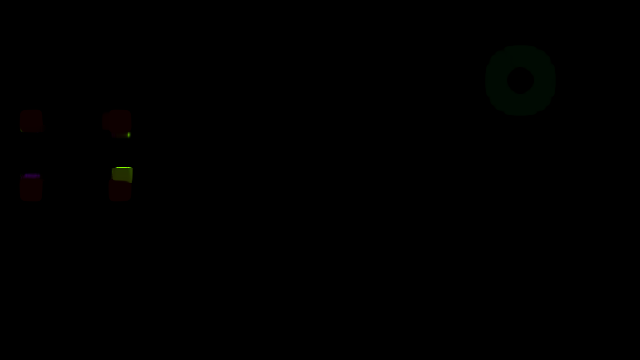

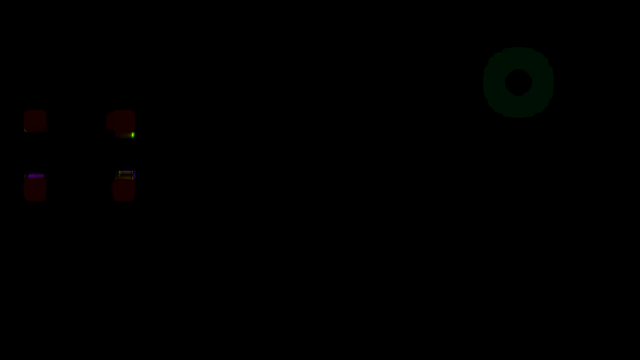

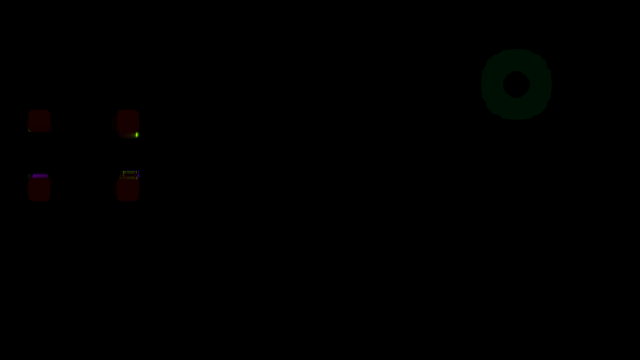

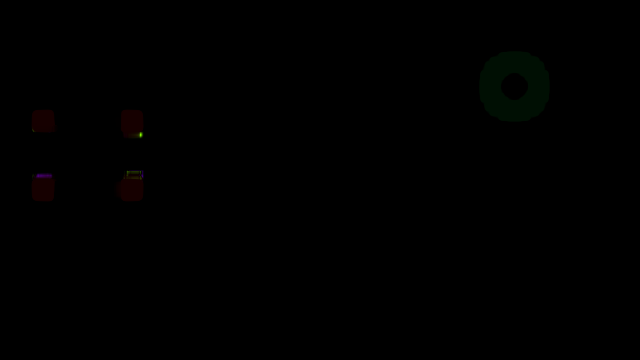

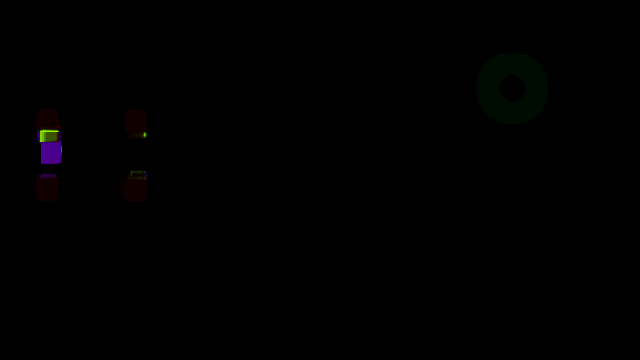

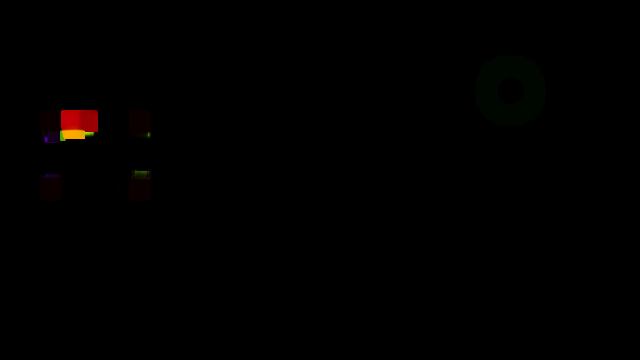

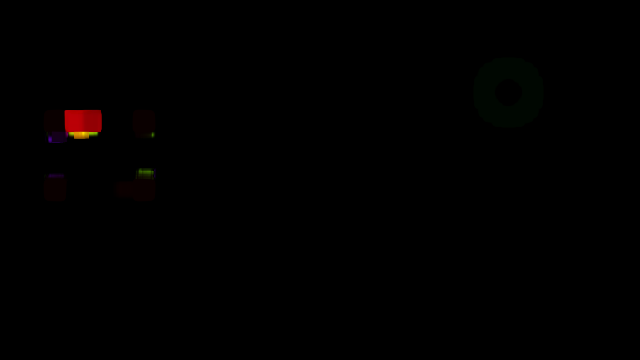

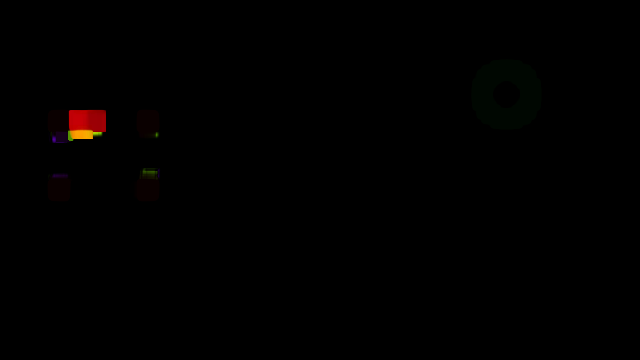

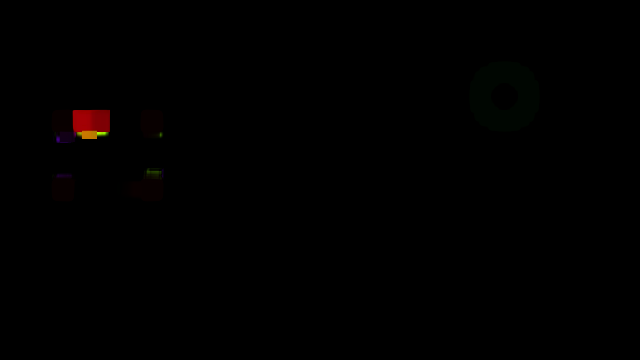

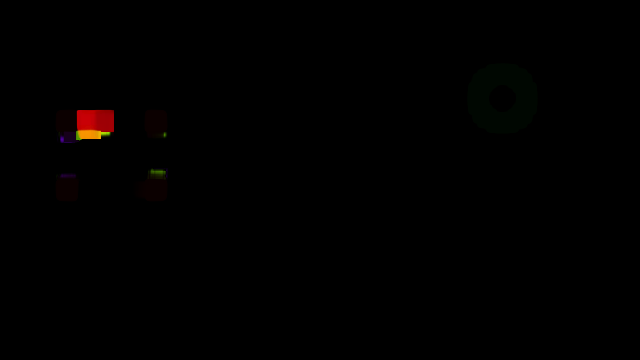

In [4]:
cap = cv2.VideoCapture(video_path)

ret, old_frame = cap.read()

old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)

for i in range(10):

    ret, frame = cap.read()

    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    flow = cv2.calcOpticalFlowFarneback(
        old_gray, gray, None,
        0.5, 3, 15, 3, 5, 1.2, 0
    )

    mag, ang = cv2.cartToPolar(
        flow[..., 0], flow[..., 1]
    )

    hsv = np.zeros_like(frame)
    hsv[..., 1] = 255
    hsv[..., 0] = ang * 90 / np.pi
    hsv[..., 2] = cv2.normalize(
        mag, None, 0, 255, cv2.NORM_MINMAX
    )

    result = cv2.cvtColor(
        hsv, cv2.COLOR_HSV2BGR
    )

    cv2_imshow(result)

    old_gray = gray.copy()

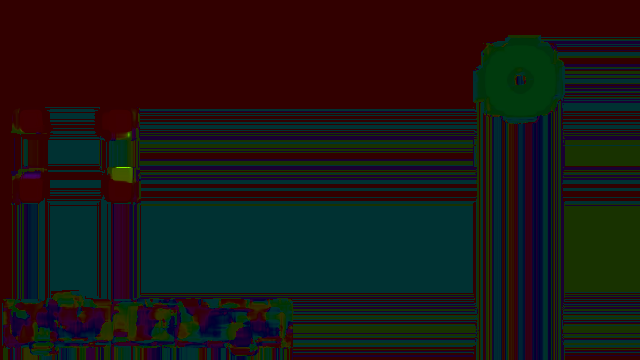

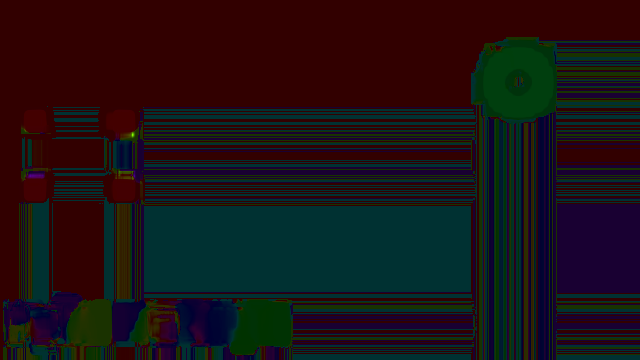

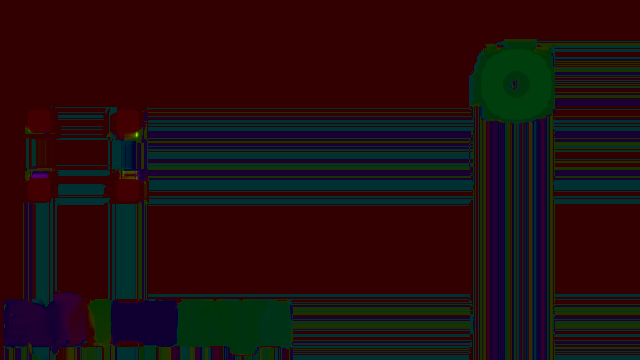

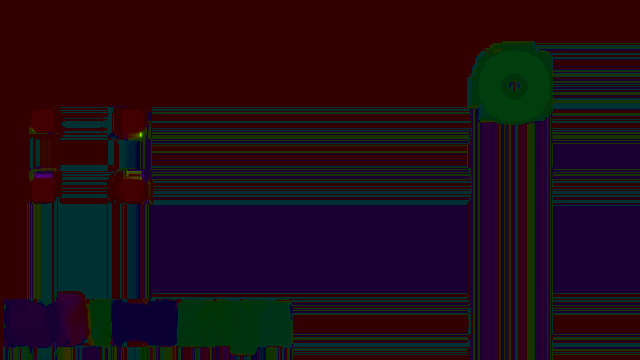

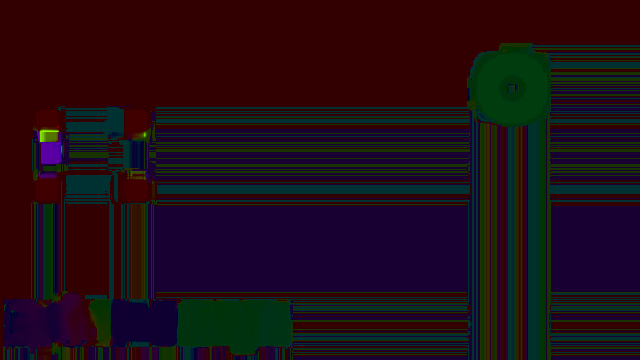

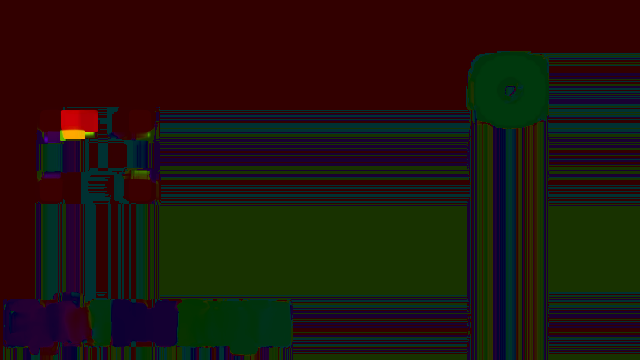

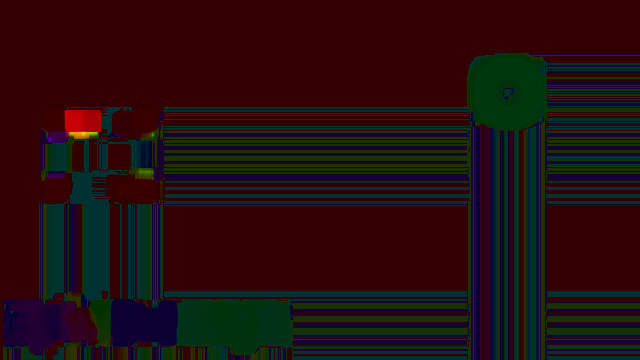

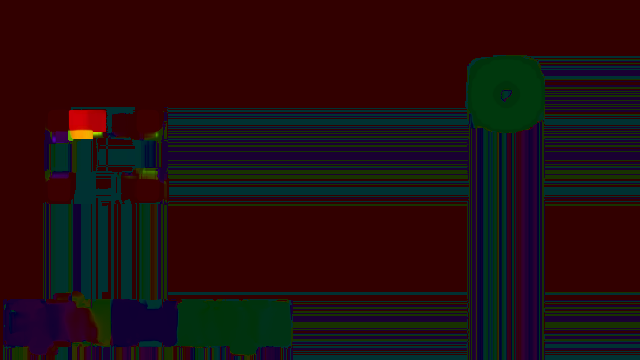

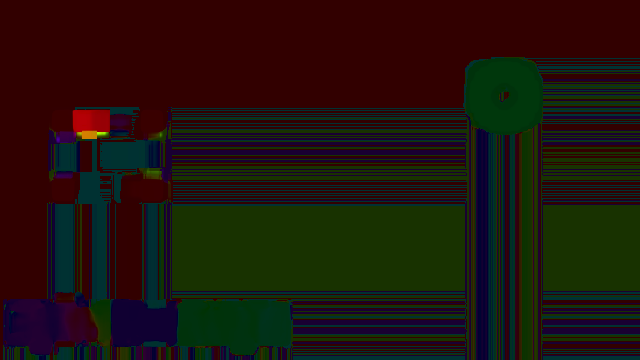

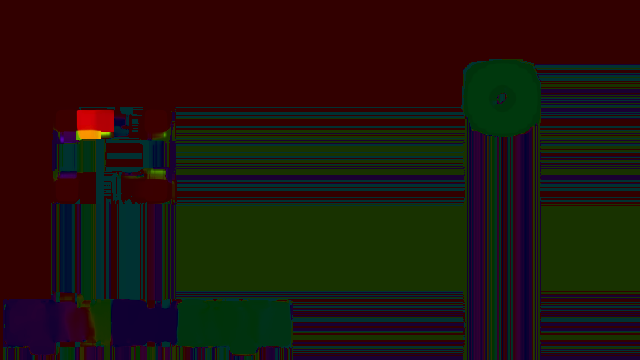

In [5]:
cap = cv2.VideoCapture(video_path)

ret, old_frame = cap.read()
old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)

for i in range(10):
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    flow = cv2.calcOpticalFlowFarneback(
        old_gray, gray, None,
        0.5, 3, 15, 3, 5, 1.2, 0
    )

    mag, ang = cv2.cartToPolar(
        flow[..., 0], flow[..., 1]
    )

    hsv = np.zeros_like(frame)
    hsv[..., 1] = 255
    hsv[..., 0] = ang * 90 / np.pi
    hsv[..., 2] = cv2.normalize(
        mag, None, 50, 255, cv2.NORM_MINMAX
    )

    result = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

    cv2_imshow(result)

    old_gray = gray.copy()

**QUESTIONS**

**Q1. How does object tracking differ from object detection?**
Object detection finds objects, while object tracking follows their movement in video frames.

Q2. How can Optical Flow be used for real-time object tracking?
It calculates pixel movement between consecutive frames to track objects.

**Q3. What is the role of Shi-Tomasi Corner Detection?**
It detects strong feature points for Lucas-Kanade tracking.

**Q4. Why is Optical Flow suitable for motion analysis in videos?**
It estimates the direction and amount of object movement.

**Q5. What challenges arise while tracking fast-moving or partially occluded objects?**
Fast motion, occlusion, blur, and sudden movement can reduce tracking accuracy.

**Q6. Compare Optical Flow-based tracking with deep learning-based tracking.**
Optical Flow is simple and fast, while deep learning tracking is more powerful but computationally expensive.

**Q7. How can Optical Flow be used in traffic monitoring and autonomous driving?**
It helps estimate vehicle movement, speed, and traffic flow.

**Q8. What is the effect of camera motion on Optical Flow?**
Camera movement creates overall scene motion and can affect object tracking accuracy.

Q9. Mention five applications of Optical Flow.
**bold text**
Object tracking
Traffic monitoring
Video surveillance
Autonomous driving
Human activity recognition

**Q10. How can Optical Flow improve surveillance, robotics, and human activity recognition?**
It helps detect, track, and analyze movement in real-time video.

Result

Optical Flow was successfully implemented using Lucas-Kanade and Farneback algorithms in Python and OpenCV.